In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

In [ ]:
def minkowski_dist(v1,v2,p):
    dist = 0.0

    for i in range(len(v1)):
        dist += abs(v1[i] - v2[i]) ** p
    return dist ** (1/p)


In [4]:
class Example(object):

    def __init__(self, name, features , label = None):
        self.name = name
        self.features = features
        self.label = label

    def dimensionality(self):
        return len(self.features)

    def set_label(self, label):
        self.label = label

    def get_features(self):
        return self.features[:]

    def get_label(self):
        return self.label

    def get_name(self):
        return self.name

    def distance(self, other):
        return minkowski_dist(self.features, other.get_features(), 2)

    def __str__(self):
        return '{} : {} : {}'.format(self.name, self.features, self.label)

In [5]:
class Cluster(object):
    def __init__(self, examples):
        self.examples = examples
        self.centroid = self.compute_centroid()

    def update(self,examples):
        old_centroid = self.centroid
        self.examples = examples
        self.centroid = self.compute_centroid()
        return old_centroid.distance(self.centroid)

    def compute_centroid(self):
        vals = np.array([0.0]*self.examples[0].dimensionlity())
        for e in self.examples:
            vals += e.get_features()
        centroid = Example('centroid', vals/len(self.examples))
        return centroid

    def get_centroid(self):
        return self.centroid

    def variability(self):
        tot_dist = 0.0
        for e in self.examples:
            tot_dist += (e.distance(self.centroid))**2
        return tot_dist

    def members(self):
        for e in self.examples:
            yield e

    def __str__(self):
        names = []
        for e in self.examples:
            names.append(e.get_name())
        names.sort()
        result = ('Cluster with centroid '
               + str(self.centroid.get_features()) + ' contains:\n  ')
        for e in names:
            result = result + e + ', '
        return result[:-2]




In [6]:
def k_means(examples, k, verbose = False):
    initial_centroids = random.sample(examples, k)
    clusters = []
    for e in initial_centroids:
        clusters.append(Cluster([e]))

    converged = False
    num_iterations = 0
    while not converged:
        num_iterations += 1
        new_clusters = []
        for i in range(k):
            new_clusters.append([])

        for e in examples:
            smallest_distance = e.distance(clusters[0].get_centroid())
            index = 0
            for i in range(1, k):
                distance = e.distance(clusters[i].get_centroid())
                if distance < smallest_distance:
                    smallest_distance = distance
                    index = i
            new_clusters[index].append(e)

        for c in new_clusters:
            if len(c) == 0:
                raise ValueError('Empty Cluster')

        converged = True
        for i in range(k):
            if clusters[i].update(new_clusters[i]) > 0.0:
                converged = False
        if verbose:
            print('Iteration #' + str(num_iterations))
            for c in clusters:
                print(c)
            print('')
    return clusters

In [7]:
def dissimilarity(clusters):
    tot_dist = 0.0
    for c in clusters:
        tot_dist += c.variability()
    return tot_dist

def try_k_means(examples, num_clusters, num_trials, verbose = False):

    best = k_means(examples, num_clusters, verbose)
    min_dissimilarity = dissimilarity(best)
    trial = 1
    while trial < num_trials:
        try:
            clusters = k_means(examples, num_clusters, verbose)
        except ValueError:
            continue
        curr_dissimilarity = dissimilarity(clusters)
        if curr_dissimilarity < min_dissimilarity:
            best = clusters
            min_dissimilarity = curr_dissimilarity
        trial += 1
    return best

AttributeError: 'Example' object has no attribute 'dimensionlity'

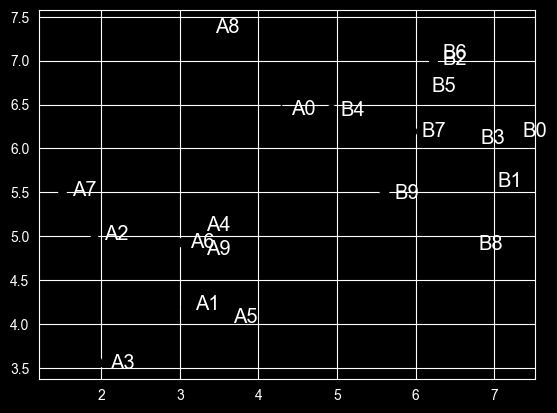

In [8]:
def gen_distribution(x_mean, x_sd, y_mean, y_sd, n, name_prefix):
    samples = []
    for s in range(n):
        x = random.gauss(x_mean, x_sd)
        y = random.gauss(y_mean, y_sd)
        samples.append(Example(name_prefix+str(s), [x, y]))
    return samples

def plot_samples(samples, marker):
    x_vals, y_vals = [], []
    for s in samples:
        x = s.get_features()[0]
        y = s.get_features()[1]
        plt.annotate(s.get_name(), xy = (x, y),
                       xytext = (x+0.13, y-0.07),
                       fontsize = 'x-large')
        x_vals.append(x)
        y_vals.append(y)
    plt.plot(x_vals, y_vals, marker)

def contrived_test(num_trials, k, verbose = False):
    x_mean = 3
    x_sd = 1
    y_mean = 5
    y_sd = 1
    n = 10
    d1_samples = gen_distribution(x_mean, x_sd, y_mean, y_sd, n, 'A')
    plot_samples(d1_samples, 'k^')
    d2_samples = gen_distribution(x_mean+3, x_sd, y_mean+1,
                                  y_sd, n, 'B')
    plot_samples(d2_samples, 'ko')
    clusters = try_k_means(d1_samples+d2_samples, k, num_trials,
                           verbose)
    print('Final result')
    for c in clusters:
        print('', c)

random.seed(1)
contrived_test(1, 2, True)
contrived_test(50, 2, False)

AttributeError: 'Example' object has no attribute 'dimensionlity'

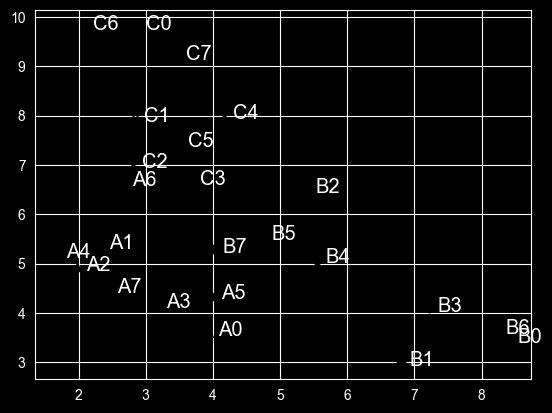

In [9]:
def contrived_test2(num_trials, k, verbose = False):
    x_mean = 3
    x_sd = 1
    y_mean = 5
    y_sd = 1
    n = 8
    d1_samples = gen_distribution(x_mean,x_sd, y_mean, y_sd, n, 'A')
    plot_samples(d1_samples, 'k^')
    d2_samples = gen_distribution(x_mean+3,x_sd,y_mean, y_sd, n, 'B')
    plot_samples(d2_samples, 'ko')
    d3Samples = gen_distribution(x_mean, x_sd, y_mean+3, y_sd, n, 'C')
    plot_samples(d3Samples, 'kx')
    clusters = try_k_means(d1_samples + d2_samples + d3Samples,
                         k, num_trials, verbose)
    plt.ylim(0, 12)
    print('Final result has dissimilarity',
          round(dissimilarity(clusters), 3))
    for c in clusters:
        print('', c)

random.seed(0)
contrived_test2(40, 2)

random.seed(0)
contrived_test2(40, 3)

random.seed(0)
contrived_test2(40, 6)